# Chapter 15 — Bayesian Inference

Updating belief with data, through Bayes’ theorem, likelihood, and posteriors.

| Section | What it covers |
|---|---|
| 15.1 | Bayes’ theorem |
| 15.2 | Likelihood |
| 15.3 | Prior to posterior |

**How to use this notebook.** Read a short explanation, run the worked cell under it, then do the
**Your turn** cell yourself. The worked cells already show their output, so you can check your
answer against them. Nothing here is graded and nothing is hidden, so break things freely and
re-run the setup cell if you get lost.

The matching page on the website is [Bayesian Inference](https://khh-aka-lucifer.github.io/statLab/chapters/bayesian-inference/), where the same ideas are
sliders and draggable points instead of code. Use both. The website builds the intuition, and the
notebook shows you how to do it to data of your own.

In [1]:
# Run me first. Everything below needs this cell.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# The same colours the StatLab website uses, so your charts match the demos.
C = {
    "accent": "#2E7D6B", "accent_strong": "#1F5A4D", "accent_soft": "#D9EBE5",
    "ink": "#282725", "ink_soft": "#6B6560", "line": "#E4E0DA",
    "cat1": "#2E7D6B", "cat2": "#B5763F", "cat3": "#4E7DA6",
    "cat4": "#9A5D8F", "cat5": "#8A8F3C",
    "ok": "#4C8B57", "warn": "#C06A2E",
}

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": C["line"], "axes.labelcolor": C["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C["line"], "grid.linewidth": 0.8,
    "text.color": C["ink"], "xtick.color": C["ink_soft"], "ytick.color": C["ink_soft"],
    "font.size": 11, "axes.titlesize": 12, "legend.frameon": False,
})

# Works whether you launched Jupyter inside code/ or at the repo root.
DATA = Path("data") if Path("data").exists() else Path("code/data")

# One seed, so your numbers match the text. Change it and the randomness changes with you.
rng = np.random.default_rng(12345)

print("Ready. pandas", pd.__version__, "| numpy", np.__version__)

Ready. pandas 3.0.3 | numpy 2.4.4


## A different question

Everything so far asked "how surprising is this data if the claim were true". Bayesian inference
asks the question most people actually have: **given this data, what should I now believe?**

Answering it requires one extra ingredient, a prior, and that is both its strength and the thing
people argue about.

## 15.1 Bayes' theorem

$$P(A \mid B) = \frac{P(B \mid A)\,P(A)}{P(B)}$$

It flips a conditional around. The classic demonstration is medical screening, where the answer is
so counter-intuitive that doctors get it wrong in studies.

A disease affects 1 % of people. A test catches 99 % of those who have it and wrongly flags 5 % of
those who do not. You test positive. What is the chance you have it?

In [2]:
prevalence, sensitivity, false_positive = 0.01, 0.99, 0.05

# do it by counting a population of 100 000, which is how to explain it to anyone
population = 100_000
ill = population * prevalence
healthy = population - ill

true_positives  = ill * sensitivity
false_positives = healthy * false_positive

print(f"of {population:,} people, {ill:,.0f} are ill and {healthy:,.0f} are healthy")
print(f"  true positives  : {true_positives:8,.0f}")
print(f"  false positives : {false_positives:8,.0f}")
print(f"  total positives : {true_positives + false_positives:8,.0f}")
print()
print(f"P(ill | positive) = {true_positives:,.0f} / {true_positives+false_positives:,.0f} "
      f"= {true_positives/(true_positives+false_positives):.4f}")

of 100,000 people, 1,000 are ill and 99,000 are healthy
  true positives  :      990
  false positives :    4,950
  total positives :    5,940

P(ill | positive) = 990 / 5,940 = 0.1667


Sixteen per cent. A test that is 99 % sensitive leaves you more likely healthy than ill, because the
5 % error rate applied to 99,000 healthy people produces far more false positives than the 99 %
catch rate applied to 1,000 ill ones.

The **prevalence** is doing the work, and it is exactly the term people drop.

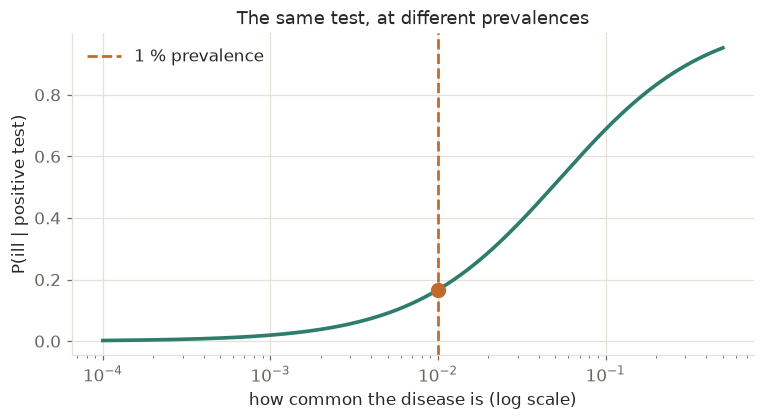

prevalence   0.1%  ->  P(ill | positive) = 0.019
prevalence   1.0%  ->  P(ill | positive) = 0.167
prevalence  10.0%  ->  P(ill | positive) = 0.688
prevalence  50.0%  ->  P(ill | positive) = 0.952


In [3]:
def posterior(prevalence, sensitivity=0.99, false_positive=0.05):
    tp = prevalence * sensitivity
    fp = (1 - prevalence) * false_positive
    return tp / (tp + fp)

rates = np.logspace(-4, -0.3, 200)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(rates, [posterior(r) for r in rates], color=C["accent"], lw=2.4)
ax.axvline(0.01, color=C["warn"], ls="--", lw=1.8, label="1 % prevalence")
ax.plot(0.01, posterior(0.01), "o", color=C["warn"], ms=9)
ax.set_xscale("log")

ax.set_xlabel("how common the disease is (log scale)"); ax.set_ylabel("P(ill | positive test)")
ax.set_title("The same test, at different prevalences")
ax.legend()
plt.show()

for r in [0.001, 0.01, 0.1, 0.5]:
    print(f"prevalence {r:6.1%}  ->  P(ill | positive) = {posterior(r):.3f}")

In [ ]:
# Your turn.
# You test positive TWICE, on two independent tests.
# 1. Use the posterior from the first test as the prior for the second.
# 2. What is P(ill | two positives)?
# 3. How many consecutive positives would you need to be 95% sure?

...

## 15.2 Likelihood

The **likelihood** scores how well each candidate value of a parameter explains the data you already
have. Same formula as a probability, read the other way round: the data is fixed and the parameter
varies.

Take a real proportion. Among Titanic passengers with a recorded sex, what share were female? Treat
the 891 passengers as a sample and ask which value of $p$ best explains it.

In [4]:
titanic = pd.read_csv(DATA / "titanic.csv")
female_count = (titanic["sex"] == "female").sum()
n = len(titanic)

print(f"{female_count} women among {n} passengers, so p-hat = {female_count/n:.4f}")

candidates = np.linspace(0.2, 0.55, 500)
likelihood = stats.binom.pmf(female_count, n, candidates)

best = candidates[np.argmax(likelihood)]
print(f"the p that maximises the likelihood is {best:.4f}")

314 women among 891 passengers, so p-hat = 0.3524
the p that maximises the likelihood is 0.3522


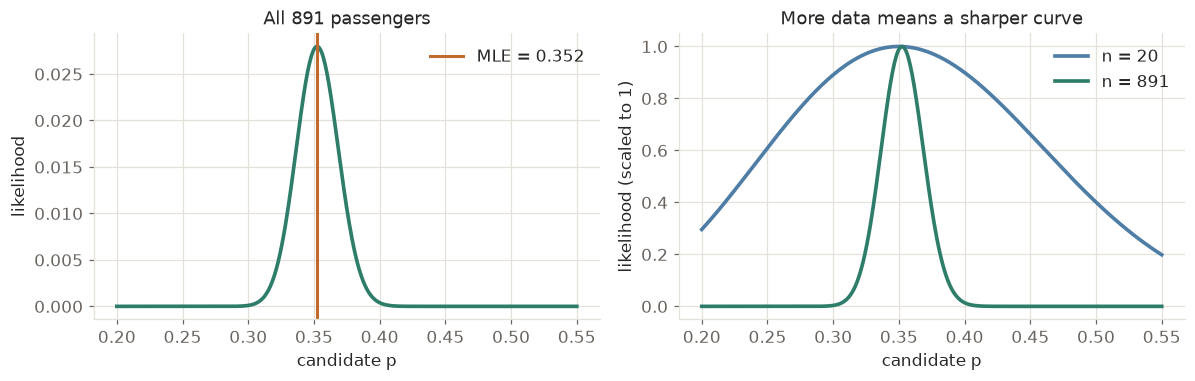

In [5]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.6))

left.plot(candidates, likelihood, color=C["accent"], lw=2.4)
left.axvline(best, color=C["warn"], lw=2, label=f"MLE = {best:.3f}")
left.set_xlabel("candidate p"); left.set_ylabel("likelihood")
left.set_title(f"All {n} passengers"); left.legend()

# with only 20 passengers the curve is far wider
small_n, small_k = 20, 7
small_like = stats.binom.pmf(small_k, small_n, candidates)
right.plot(candidates, small_like / small_like.max(), color=C["cat3"], lw=2.4, label="n = 20")
right.plot(candidates, likelihood / likelihood.max(), color=C["accent"], lw=2.4, label=f"n = {n}")
right.set_xlabel("candidate p"); right.set_ylabel("likelihood (scaled to 1)")
right.set_title("More data means a sharper curve"); right.legend()

plt.tight_layout()
plt.show()

Two things about that curve. It is not a probability distribution for $p$, so its area is not 1 and
you cannot read "the probability that $p$ is 0.35" off it. Only ratios carry meaning: a $p$ that is
ten times less likely explains the data ten times worse.

And more data narrows it. That is the same story as the standard error, arriving by another route.

In [ ]:
# Your turn.
# Build the likelihood curve for the survival rate using the real counts.
# 1. Find the maximum likelihood estimate and check it equals the sample proportion.
# 2. Find the range of p values whose likelihood is at least 1/8 of the maximum.
#    That interval is a "likelihood interval". Compare it with the Chapter 8 confidence interval.

...

## 15.3 Prior to posterior

Bayesian updating combines a **prior**, what you believed beforehand, with the **likelihood**, what
the data says, to give a **posterior**, what you believe now.

For a proportion there is a shortcut. If the prior is a Beta distribution, the posterior is one too,

$$\text{Beta}(a, b) + k \text{ successes in } n \text{ trials} \;\to\; \text{Beta}(a + k,\; b + n - k)$$

Every observation simply adds to a shape parameter, so the prior behaves like data you already had.

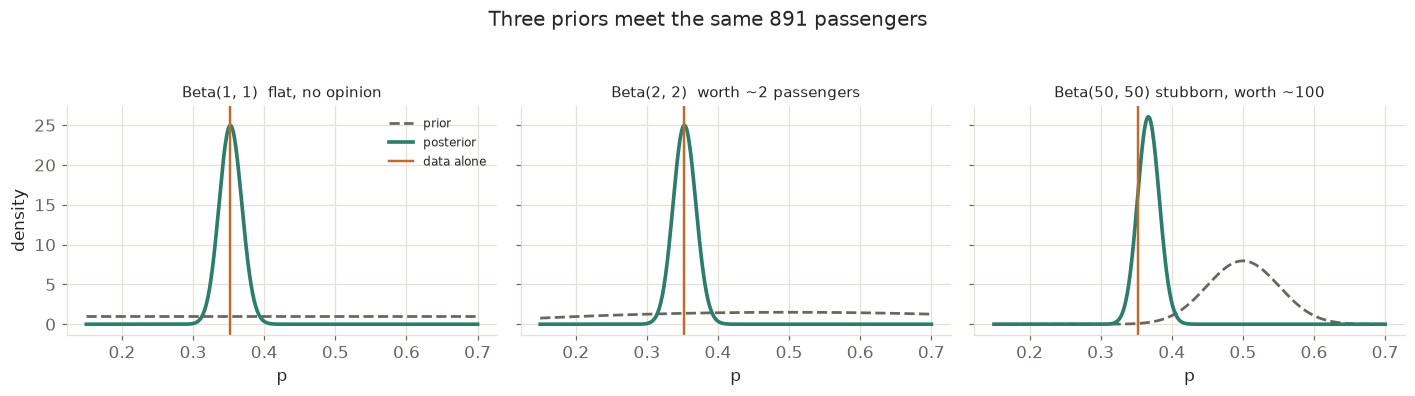

In [6]:
k, n = female_count, len(titanic)

priors = {
    "Beta(1, 1)  flat, no opinion":        (1, 1),
    "Beta(2, 2)  worth ~2 passengers":     (2, 2),
    "Beta(50, 50) stubborn, worth ~100":   (50, 50),
}

grid = np.linspace(0.15, 0.7, 500)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
for ax, (label, (a, b)) in zip(axes, priors.items()):
    ax.plot(grid, stats.beta.pdf(grid, a, b), color=C["ink_soft"], ls="--", lw=1.8, label="prior")
    ax.plot(grid, stats.beta.pdf(grid, a + k, b + n - k), color=C["accent"], lw=2.4, label="posterior")
    ax.axvline(k/n, color=C["warn"], lw=1.6, label="data alone")
    ax.set_title(label, fontsize=10); ax.set_xlabel("p")
axes[0].set_ylabel("density"); axes[0].legend(fontsize=8)

fig.suptitle(f"Three priors meet the same {n} passengers", y=1.05)
plt.tight_layout()
plt.show()

All three posteriors land in essentially the same place. With 891 observations the prior is
overwhelmed, and even the stubborn Beta(50, 50) barely shifts the answer.

That is the usual situation and it is reassuring. Priors matter when data is scarce, and stop
mattering once it is plentiful. Watch that happen directly.

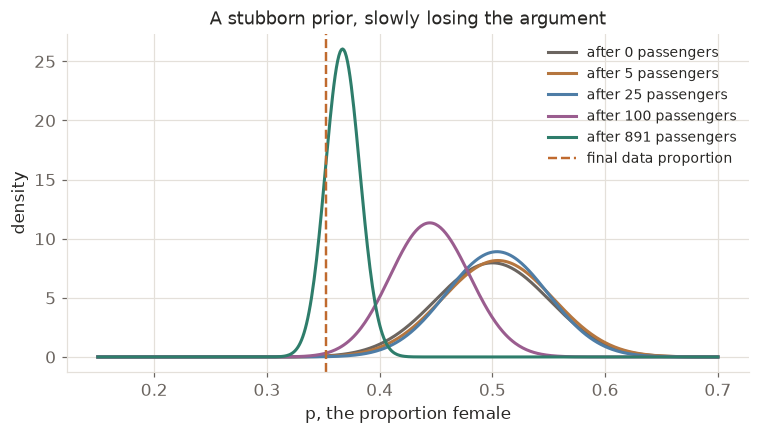

In [7]:
a_prior, b_prior = 50, 50          # the stubborn prior
observed = (titanic["sex"] == "female").to_numpy()

fig, ax = plt.subplots(figsize=(8, 4))
for m, colour in [(0, C["ink_soft"]), (5, C["cat2"]), (25, C["cat3"]),
                  (100, C["cat4"]), (891, C["accent"])]:
    k_so_far = observed[:m].sum()
    ax.plot(grid, stats.beta.pdf(grid, a_prior + k_so_far, b_prior + m - k_so_far),
            color=colour, lw=2, label=f"after {m} passengers")
ax.axvline(k/n, color=C["warn"], ls="--", lw=1.6, label="final data proportion")

ax.set_xlabel("p, the proportion female"); ax.set_ylabel("density")
ax.set_title("A stubborn prior, slowly losing the argument")
ax.legend(fontsize=9)
plt.show()

In [8]:
# the Bayesian answer, stated the way people want to hear it
a_post, b_post = 1 + k, 1 + n - k          # flat prior
lo, hi = stats.beta.ppf([0.025, 0.975], a_post, b_post)

print(f"posterior mean: {a_post/(a_post+b_post):.4f}")
print(f"95% credible interval: ({lo:.4f}, {hi:.4f})")
print()
print("A credible interval says: given the data and the prior, there is a 95 % probability")
print("that p lies in here. A confidence interval is NOT allowed to say that.")

posterior mean: 0.3527
95% credible interval: (0.3217, 0.3844)

A credible interval says: given the data and the prior, there is a 95 % probability
that p lies in here. A confidence interval is NOT allowed to say that.


That last distinction is the real payoff. A confidence interval is a statement about the long-run
behaviour of a procedure. A credible interval is a statement about the parameter, which is what
everyone wants and what most people wrongly believe a confidence interval provides.

You pay for it with the prior. With plenty of data the two intervals nearly coincide, so the
argument is mostly about what to do when data is scarce.

In [9]:
freq_lo, freq_hi = stats.norm.interval(0.95, k/n, np.sqrt((k/n)*(1-k/n)/n))
print(f"Bayesian credible interval (flat prior): ({lo:.4f}, {hi:.4f})")
print(f"frequentist confidence interval:         ({freq_lo:.4f}, {freq_hi:.4f})")
print("\nNearly identical here, because 891 observations drown any reasonable prior.")

Bayesian credible interval (flat prior): (0.3217, 0.3844)
frequentist confidence interval:         (0.3210, 0.3838)

Nearly identical here, because 891 observations drown any reasonable prior.


In [ ]:
# Your turn.
# A new penguin colony is found and you check 8 birds: 3 are female.
# 1. With a flat Beta(1,1) prior, what is the posterior for the proportion female?
# 2. With a Beta(20,20) prior encoding "colonies are usually near 50/50", what changes?
# 3. Plot both. With only 8 birds, how much does the prior matter now?

...

## Exercises

1. **The base rate, again.** Redo the medical test with a disease affecting 1 in 10,000 people.
   Then find the sensitivity and specificity a test would need for a positive result to mean a
   50 % chance of illness.

2. **Sequential updating.** Feed the Titanic passengers in one at a time and record the posterior
   mean after each. Plot it. Compare against the running sample proportion from Chapter 3.

3. **The prior as data.** Show numerically that a Beta$(a, b)$ prior is worth exactly $a + b - 2$
   observations, by finding the sample size at which the data and the prior contribute equally.

4. **Credible against confidence.** For $n = 10$ with 3 successes, compute both intervals. They will
   differ noticeably. Which one would you rather report, and to whom?

5. **A prior you can defend.** Pick a real question from the penguin data, such as the proportion of
   Adelie that are female. Write down a prior before looking, justify it in a sentence, then update
   it with the data and see how badly you did.

## What you should take away

Bayes' theorem flips a conditional, and the medical-test example shows why the base rate cannot be
dropped: a 99 % accurate test on a 1 % disease still leaves you probably healthy.

Likelihood scores parameters against fixed data and is not a probability distribution over the
parameter. Turning it into one requires a prior, and the Beta-Binomial pair makes that arithmetic
trivial for proportions.

With plenty of data the prior stops mattering and Bayesian and frequentist answers converge. The
lasting difference is what you are allowed to say, because only the credible interval makes a
probability statement about the parameter itself.

---

*StatLab, by Dr. Sein Minn and Kaung Hein Htet. Code MIT, text CC BY 4.0.
Follows OpenStax [Introductory Statistics](https://openstax.org) (Illowsky & Dean, CC BY 4.0).*